# Exercise 5

In [2]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

In [3]:
J=5
h=1/(J+1)
alpha=1
beta=2

In [4]:
def phi(x,j):
    if x< (j-1)*h: return 0
    elif x< j*h: return 1+ (x-j*h)/h
    elif x<(j+1)*h: return 1- (x-j*h)/h
    else: return 0

In [5]:
def phi_prime(x,j):
    if x< (j-1)*h: 
        return 0
    elif x<j*h: 
        return 1/h
    elif x< (j+1)*h:
        return -1/h
    else: 
        return 0

In [6]:
def phi_prime_phi_prime(x,i,j):
    return phi_prime(x,i)*phi_prime(x,j)

In [7]:
Ah=np.zeros((J,J),float)

for i in range(J):
    for j in range(J):
        integral, error = quad(phi_prime_phi_prime, 0, 1, args= (1+i, j+1))
        Ah[i, j] = integral

In [8]:
def f(x): return 12*(x**2)

def f_times_phi(x,j):
    return f(x)*phi(x,j)

In [9]:
Fh=np.zeros((J), float)

for i in range(J):
    j=i+1
    integral,error= quad(f_times_phi, 0, 1, args=(j))
    Fh[i]=integral

In [10]:
Uh= np.linalg.solve(Ah,Fh)
#Uh= np.allclose(Ah @ Uh, Fh)

def u_lifted(x): #u tilde
    val=0
    for j in range(1,J+1):
        val+=Uh[j-1]*phi(x,j)
    return val

In [11]:
def u0(x):
    return (alpha+ (beta-alpha)*x)

def u_unlifted(x):
    return u_lifted(x)+ u0(x)

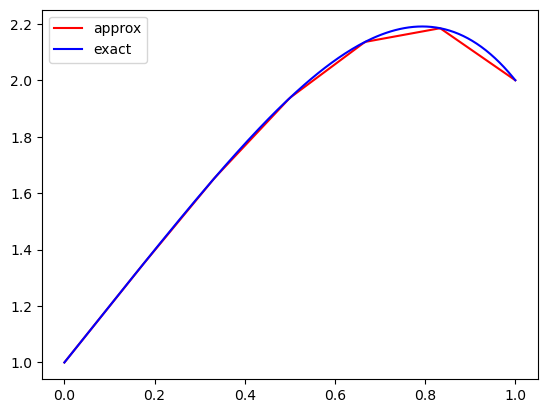

In [12]:
Nx=200

x=np.arange(Nx, dtype=float)
y=np.arange(Nx, dtype=float)

s=0

for t in np.linspace(0.0, 1.0, Nx):
    x[s]=t
    y[s]= u_unlifted(t)
    s+= 1

z= np.arange(Nx, dtype=float)

s=0
for t in np.linspace(0.0, 1.0, Nx):
    z[s]=-(t**4)+ 2*t+1
    s+= 1


plt.plot(x,y, "r", label="approx")
plt.plot(x,z, "b", label="exact")
plt.legend()
plt.show()


# exercise 6

exactly the same code but with sin(pi*x), exact solution is sin(pix)/pi^2 +x + 1

# exercise 7

compute the rigidity matrix using the lecture

In [13]:
Ah_lecture= np.zeros_like(Ah)

for i in range(J):
    j=i+1
    Ah_lecture[i,i]=2.0/h

for i in range(J-1):
    j=i+Ah
    Ah_lecture[i,i+1]=-1/h
    Ah_lecture[i+1,i]=-1/h

print(Ah)


[[12. -6.  0.  0.  0.]
 [-6. 12. -6.  0.  0.]
 [ 0. -6. 12. -6.  0.]
 [ 0.  0. -6. 12. -6.]
 [ 0.  0.  0. -6. 12.]]


# exercise 8: using fenics

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


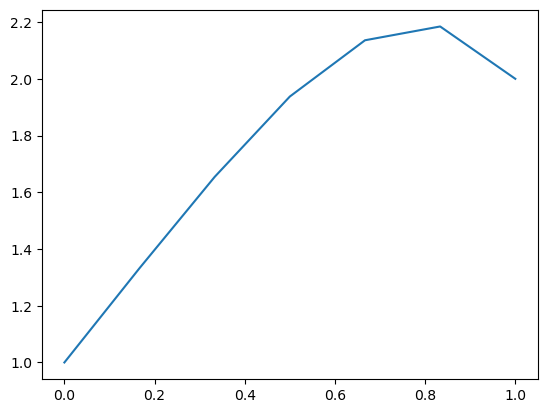

In [3]:
# create a mesh on the interval [0,1] with n divisions
from fenics import *

J=5
h=1/(J+1)
alpha=1
beta=2

mesh= IntervalMesh(J+1, 0.0, 1.0)

# def function
V= FunctionSpace(mesh, "P", 1)

u0=Constant(1.0)
u1=Constant(2.0)
bc0= DirichletBC(V, u0, "on_boundary && near(x[0], 0.0)")
bc1= DirichletBC(V, u1, "on_boundary && near(x[0], 1.0)")


# def source term f(x)= -12 x^2

f= Expression("12 * pow(x[0], 2)", degree=2)

u=TrialFunction(V)
v=TestFunction(V)
a=dot(grad(u), grad(v))*dx 
L= f*v*dx 

A,b= assemble_system(a,L, [bc0, bc1])

u_sol = Function(V)
solve(A, u_sol.vector(), b)
plot(u_sol)
